**Open h5 results file**

This code opens the h5 file and prints its structure, to make easier to find objects

In [ ]:
# Open h5 file and import necessary modules
import h5py

def inspect_h5_file(file_path):
    def print_structure(name, obj):
        # Evaluate needed identation based on the depth in the hierarchy
        indent = '  ' * name.count('/')

        if isinstance(obj, h5py.Group):
            print(f"{indent}Group: {name}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}Dataset: {name} - Shape: {obj.shape}, Dtype: {obj.dtype}")

            if obj.attrs:
                for attr_name, attr_value in obj.attrs.items():
                    print(f"{indent}  Attribute: {attr_name} = {attr_value}")

    print(f"Inspecting HDF5 file: {file_path}")
    with h5py.File(file_path, 'r') as h5file:
        h5file.visititems(print_structure)

# Example usage
file_path = r'output\backbone_2026_20260327170054-1\optimization_results.h5'
inspect_h5_file(file_path)

Just to open the h5 file and scratch into the sizes of components

In [ ]:
from __future__ import annotations
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

def _to_scalar(x):
    """
    Convert dataset HDF5 to Python scalar if possible.
    Handles: scalars, 0-d arrays, 1-element arrays.
    """
    if isinstance(x, (np.generic,)):
        return float(x.item())
    x = np.asarray(x)
    if x.shape == ():          # 0-d
        return float(x.item())
    if x.size == 1:
        return float(x.reshape(-1)[0].item())
    return x  # if it's a real array (should not be for capex_tot)

def create_base_df(h5_path: str | Path,
                   year: str = "2022") -> pd.DataFrame:
    """
    Check structure of the HDF5 file and create a base DataFrame for design results.
    DF structure:
    | node | component |
    """
    h5_path = Path(h5_path)

    rows = []
    base = f"design/nodes/{year}"
    
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")

        g_year = f[base]

        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]

            for comp in g_node.keys():
                rows.append({"node": node, "component": comp})
        
    df = pd.DataFrame(rows)

    return df
        

def load_design_results(dataset_name: str,
                      h5_path: str | Path,
                      year: str = "2022",
                      base_df: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Extracts dataset_name for each component: design/nodes/{year}/{node}/{component}/{dataset_name}
    Adds dataset_name to the base DataFrame created by create_base_df.
    DF structure:
    | node | component | dataset_name |
    """
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"

    if base_df is None:
        df = create_base_df(h5_path, year)
    else:
        df = base_df.copy()
        if not isinstance(df.index, pd.MultiIndex) or df.index.names != ['node', 'component']:
            df = df.set_index(['node', 'component']).sort_index()

    # Add dataset_name to the base DataFrame created by create_base_df
    df[dataset_name] = np.nan  # initialize column dataset_name with NaN

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        
        g_year = f[base]

        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]

            for comp in g_node.keys():
                ds_path = f"{g_node_path}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    # # Check if the node/component pair exists in the base DataFrame
                    # mask = (df['node'] == node) & (df['component'] == comp)
                    # if mask.any():
                    #     df.loc[mask, dataset_name] = val
                    # else:
                    #     print(f"Warning: node/component pair ({node}, {comp}) not found in base DataFrame. Skipping {dataset_name} for this pair.")
                    df.loc[(node, comp), dataset_name] = val

    return df.reset_index()

results_path = r"output\current_layout_optimal\optimization_results.h5"
year = '2022'

# Create standard df for design results
components_df = create_base_df(results_path, year)

# Load capex data
components_df = load_design_results("capex_tot", results_path, year, components_df)

# Load size data
components_df = load_design_results("size", results_path, year, components_df)

print(components_df)

**Pipeline design map**

This code opens the h5 file and plots the map according to the positions of the nodes and the installed pipeline. Thickness of the lines is based on **design** variable

In [ ]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

def _to_scalar(x):
    """Convert HDF5 dataset to Python scalar if possible, with special handling for bytes -> str."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == ():
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    if x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    # array vero
    if x.dtype.kind in ("S", "O"):
        try:
            return np.vectorize(lambda b: b.decode("utf-8") if isinstance(b, (bytes, bytearray)) else b)(x)
        except Exception:
            pass
    return x

def read_network_edges(h5_path: str | Path,
                       year: str = "2022",
                       network: str = "hydrogenPipelineOnshore",
                       dataset: str = "capex") -> pd.DataFrame:
    """
    design/networks/{year}/{network}/{edge_id}/...
    Reads the selected dataset along with fromNode and toNode if they exist.
    """
    h5_path = Path(h5_path)
    base = f"design/networks/{year}/{network}"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g = f[base]
        edge_ids = list(g.keys())

        rows = []
        for eid in edge_ids:
            row = {"edge_id": eid}

            p_val = f"{base}/{eid}/{dataset}"
            p_from = f"{base}/{eid}/fromNode"
            p_to = f"{base}/{eid}/toNode"

            row[dataset] = _to_scalar(f[p_val][()]) if p_val in f else np.nan
            row["fromNode"] = _to_scalar(f[p_from][()]) if p_from in f else np.nan
            row["toNode"] = _to_scalar(f[p_to][()]) if p_to in f else np.nan
            rows.append(row)

    return pd.DataFrame(rows)

def attach_geometry(edges_df: pd.DataFrame, nodes_csv: str | Path) -> pd.DataFrame:
    """
    Adds lon/lat columns for from/to using plants_clusters_summary.csv
    (expected columns: cluster, latitude, longitude)
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    coords = nodes.set_index("cluster")[["latitude", "longitude"]]

    out = edges_df.copy()
    out["fromNode"] = out["fromNode"].astype(str)
    out["toNode"]   = out["toNode"].astype(str)

    out["from_lat"] = out["fromNode"].map(coords["latitude"])
    out["from_lon"] = out["fromNode"].map(coords["longitude"])
    out["to_lat"]   = out["toNode"].map(coords["latitude"])
    out["to_lon"]   = out["toNode"].map(coords["longitude"])
    return out

def make_geopandas_map(edges_df: pd.DataFrame,
                       nodes_csv: str | Path,
                       weight_col: str = "capex",
                       bbox=(2.0, 49.0, 9.5, 54.0),
                       min_width=0.5,
                       max_width=6.0,
                       title=None):
    """
    Plots with GeoPandas + Matplotlib:
    - NaturalEarth basemap
    - nodes as points
    - edges as LineString with linewidth scaled on weight_col
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    # GeoDataFrame nodes
    g_nodes = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326"
    )

    # Filter valid edges and create LineString
    ed = edges_df.copy()
    ed[weight_col] = pd.to_numeric(ed[weight_col], errors="coerce")

    valid = ed[["from_lon","from_lat","to_lon","to_lat"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()

    ed["geometry"] = ed.apply(
        lambda r: LineString([(r["from_lon"], r["from_lat"]), (r["to_lon"], r["to_lat"])]),
        axis=1
    )
    g_edges = gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:4326")

    # Clip on bbox (lon_min, lat_min, lon_max, lat_max)
    lon_min, lat_min, lon_max, lat_max = bbox
    g_nodes_roi = g_nodes.cx[lon_min:lon_max, lat_min:lat_max]
    g_edges_roi = g_edges.cx[lon_min:lon_max, lat_min:lat_max]

    # Basemap
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    world_roi = world.cx[lon_min:lon_max, lat_min:lat_max]

    # Scale linewidth
    w = g_edges_roi[weight_col].to_numpy(dtype=float)
    w_pos = w[np.isfinite(w) & (w > 0)]
    w_max = float(w_pos.max()) if w_pos.size else 0.0

    def _lw(val):
        if not np.isfinite(val) or val <= 0 or w_max <= 0:
            return 0.0
        return min_width + (max_width - min_width) * (val / w_max)

    g_edges_roi["lw"] = g_edges_roi[weight_col].apply(_lw)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 9))
    world_roi.plot(ax=ax, color="#f0f0f0", edgecolor="#888888", linewidth=0.5)

    # plot edges: draw only those with lw>0 (so zeros don't "pollute")
    g_edges_plot = g_edges_roi[g_edges_roi["lw"] > 0]
    if len(g_edges_plot):
        for lw_i in sorted(g_edges_plot["lw"].unique()):
            g_edges_plot[g_edges_plot["lw"] == lw_i].plot(ax=ax, linewidth=lw_i, alpha=0.8)

    # nodes
    g_nodes_roi.plot(ax=ax, markersize=35, alpha=0.9)

    # node labels (optional: comment out if cluttered)
    for _, r in g_nodes_roi.iterrows():
        ax.text(r["longitude"] + 0.05, r["latitude"] + 0.05, str(r["cluster"]), fontsize=9)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title or f"Network {weight_col} (scaled linewidth)")
    ax.grid(True, linewidth=0.2, alpha=0.4)

    return fig, ax, g_nodes_roi, g_edges_roi


# main
h5_path = r"output\2030\optimization_results.h5"
nodes_csv = r"case_studies\2030\plants_clusters_summary.csv"
year = "2022"

edges = read_network_edges(h5_path, year=year, network="hydrogenPipelineOnshore", dataset="capex")
edges = attach_geometry(edges, nodes_csv)

fig, ax, g_nodes_roi, g_edges_roi = make_geopandas_map(
    edges, nodes_csv, weight_col="capex",
    title="Hydrogen pipeline CAPEX"
)
plt.show()


Plots on costs of the components (CAPEX + OPEX) and costs/revenues of the carriers

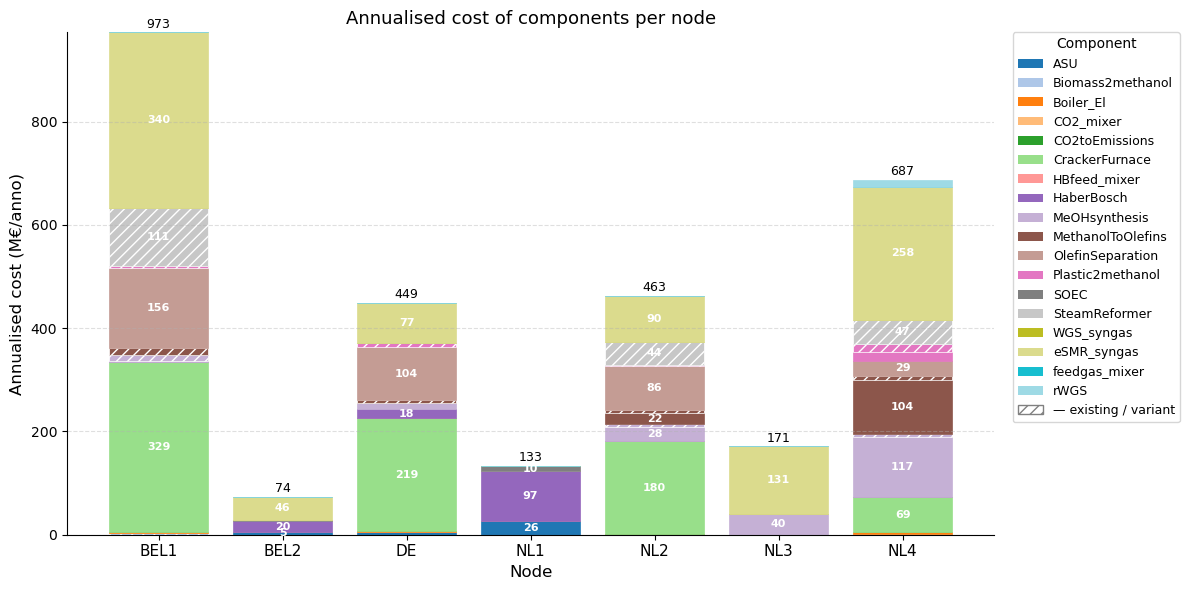

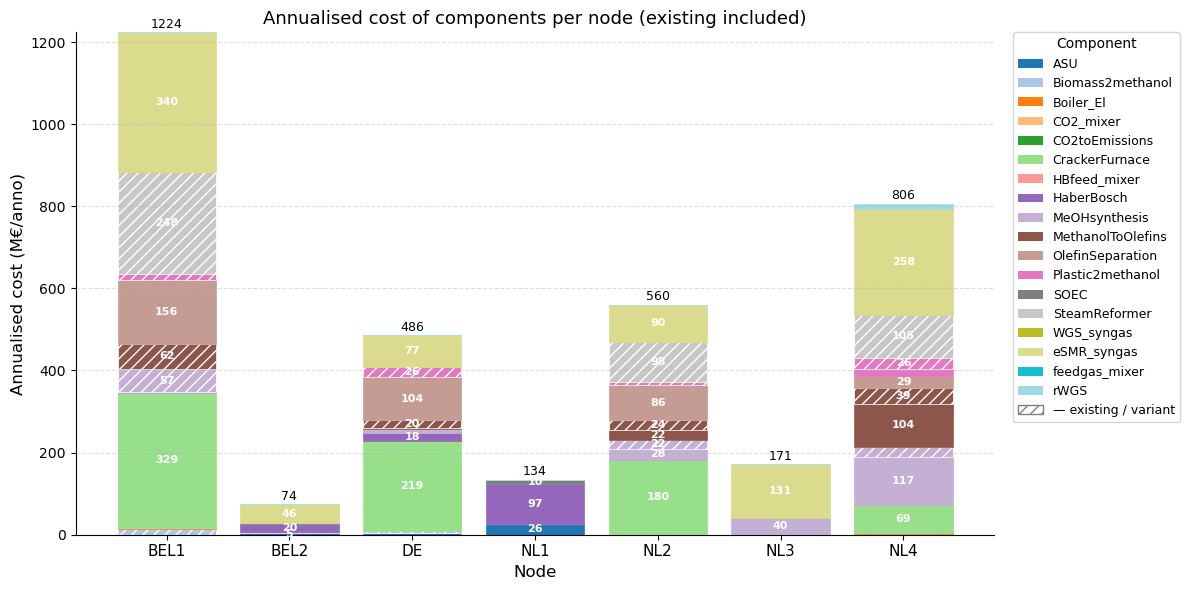

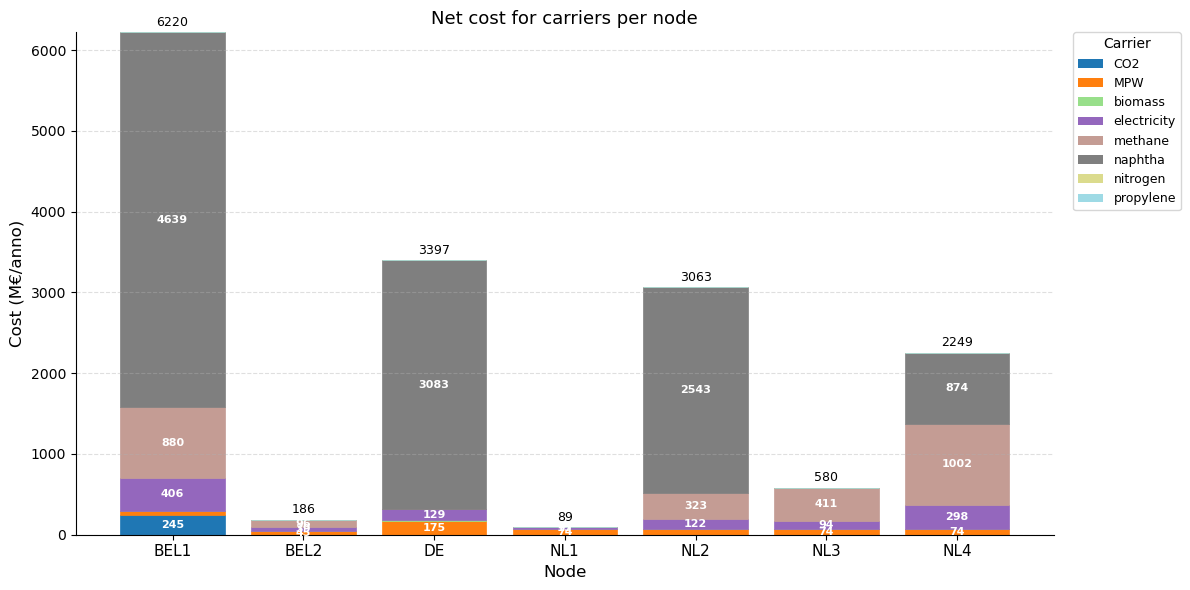

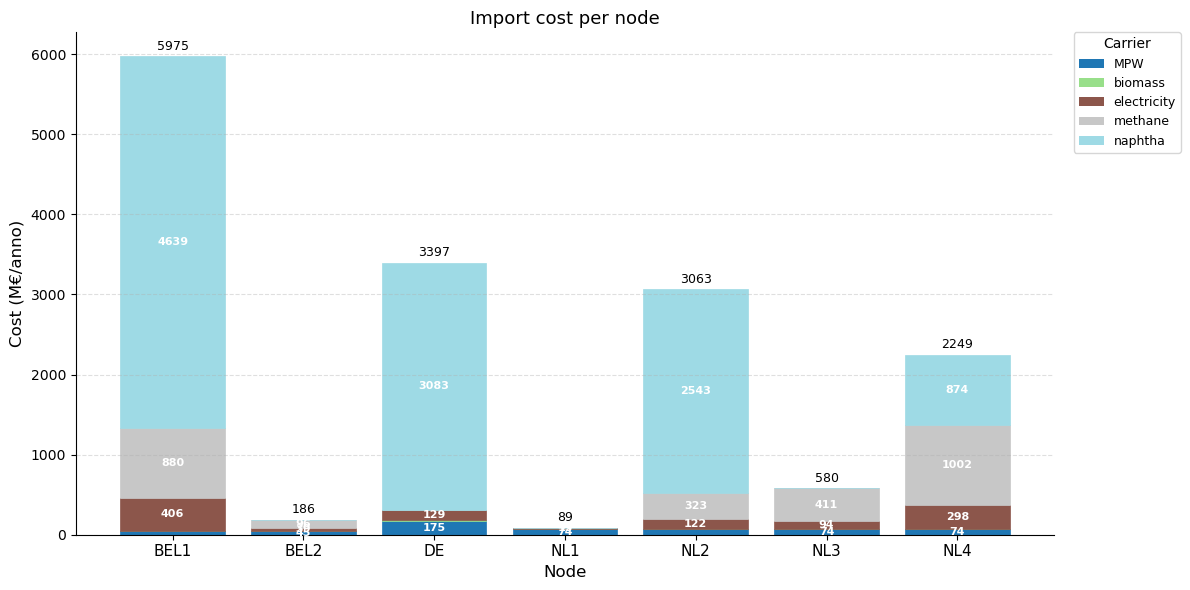

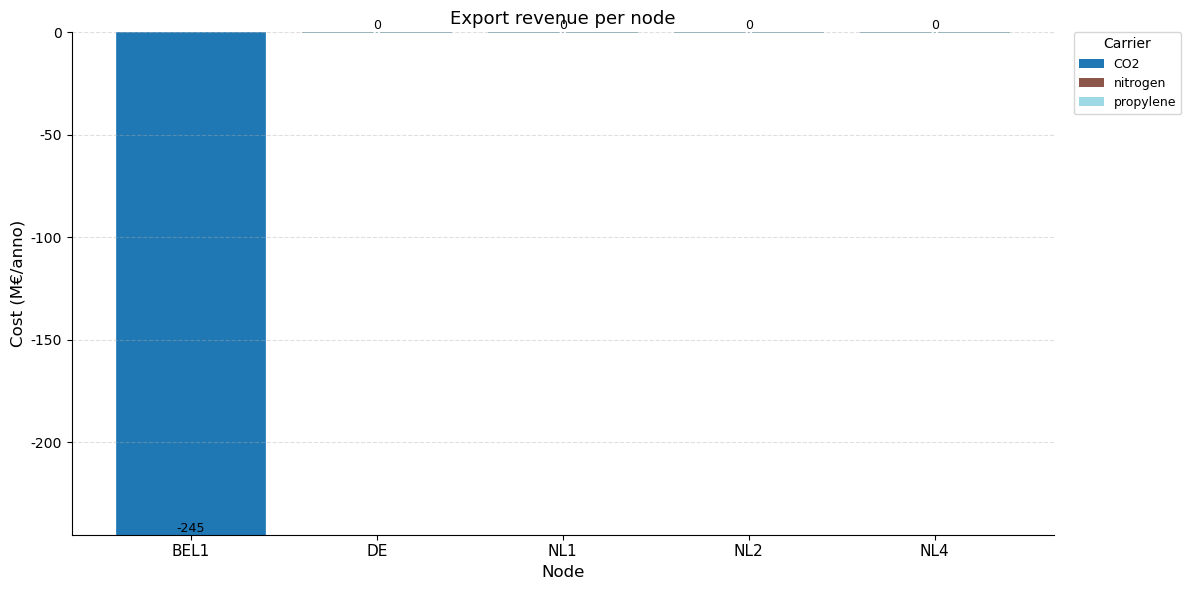

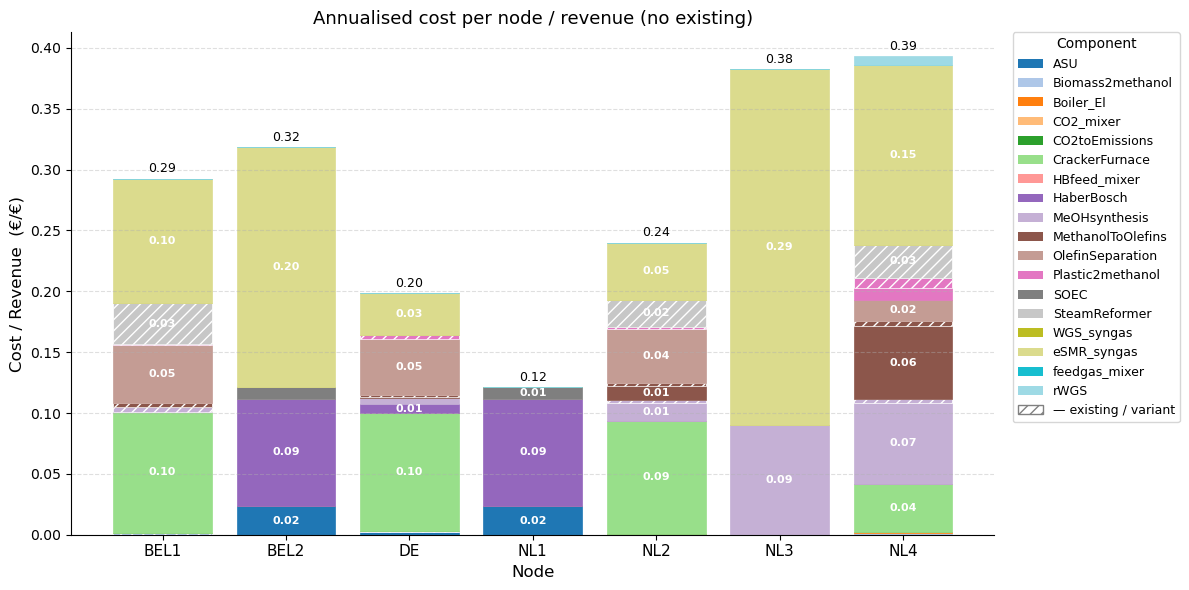

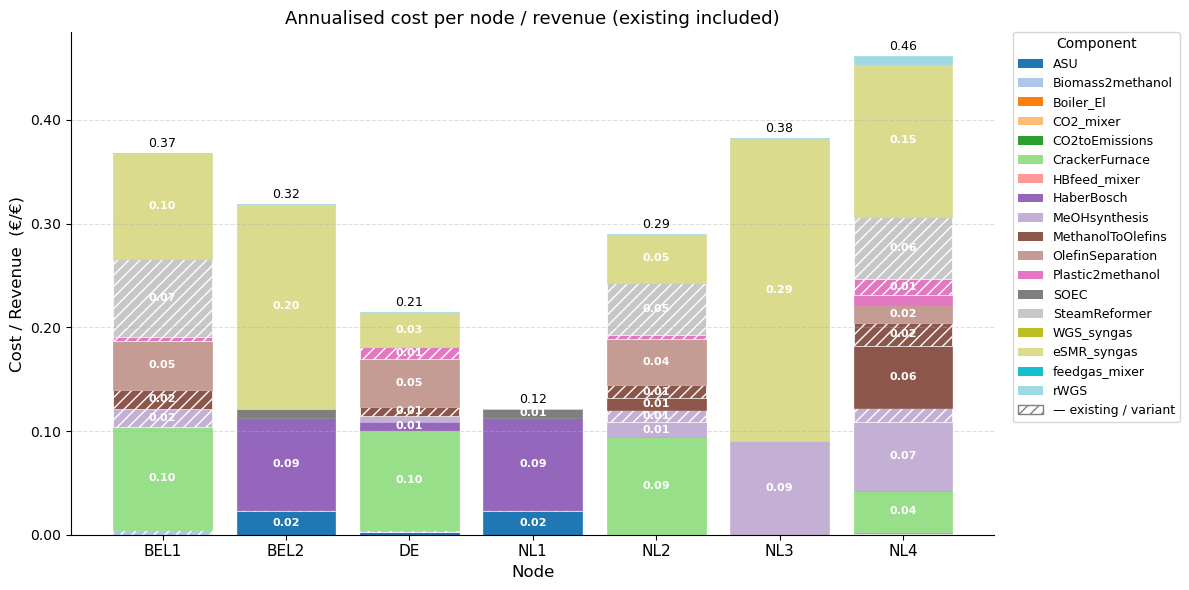

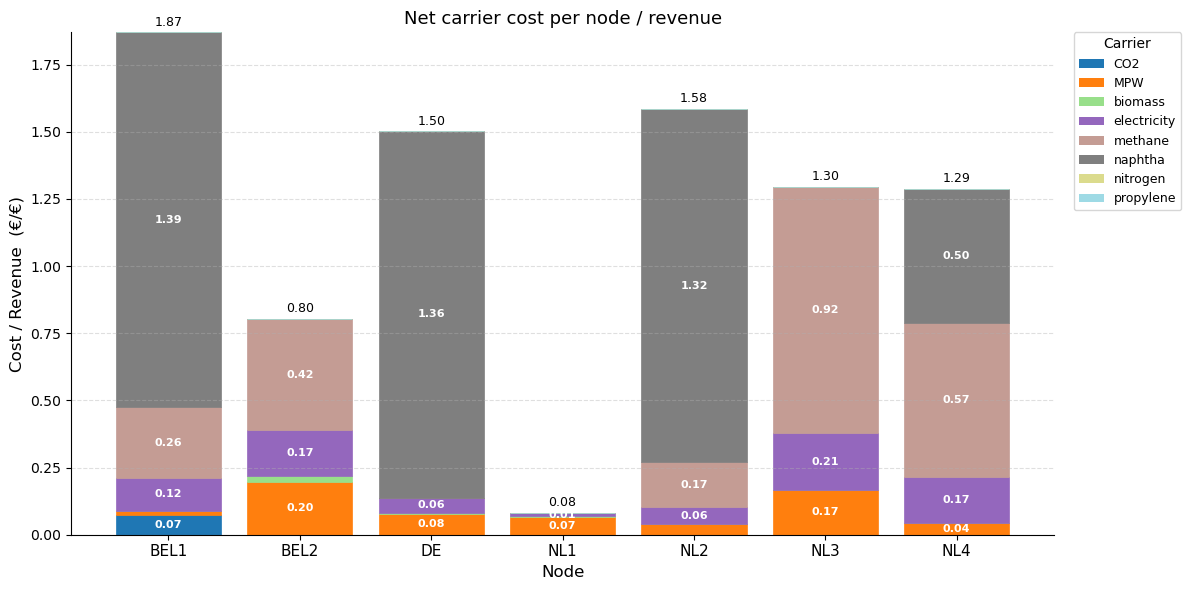

In [5]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


# ─────────────────────────────────────────────
#  HDF5 helpers
# ─────────────────────────────────────────────

def _to_scalar(x):
    """HDF5 dataset -> python scalar, decodes bytes."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


def _annualise(unit_capex: float, size: float,
               discount_rate: float, lifetime: int) -> float:
    """
    Evaluates annualised CAPEX for a component of given size, using the formula:
        CRF = r*(1+r)^n / ((1+r)^n - 1)
        annualized_capex = unit_capex * size * CRF
    where r = discount_rate, n = lifetime.
    """
    r, n = discount_rate, lifetime
    crf = r * (1 + r)**n / ((1 + r)**n - 1)
    return unit_capex * size * crf


def _find_json_recursive(technology_data_root: str | Path, tec_name: str) -> Path | None:
    """
    Searches recursively in technology_data_root for a file named '{tec_name}.json'.
    Returns the Path if found, else None. If multiple matches are found, a warning is printed and the first one is returned.
    """
    root = Path(technology_data_root)
    matches = list(root.rglob(f"{tec_name}.json"))
    if not matches:
        return None
    if len(matches) > 1:
        print(f"[Warning] Found {len(matches)} files for '{tec_name}', using the first: {matches[0]}")
    return matches[0]


def create_base_df(h5_path: str | Path, year: str = "2022") -> pd.DataFrame:
    """Returns all (node, component) pairs under design/nodes/{year}."""
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for node in f[base].keys():
            for comp in f[base][node].keys():
                rows.append({"node": str(node), "component": str(comp)})
    return pd.DataFrame(rows)


def load_technologies_design_results(
    dataset_name: str, # e.g. 'capex_tot', 'opex_fixed', 'opex_variable'
    h5_path: str | Path,
    year: str = "2022",
    base_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Adds a column with dataset_name values to base_df."""
    h5_path = Path(h5_path)
    df = base_df.copy() if base_df is not None else pd.DataFrame()
    df[dataset_name] = np.nan
    base = f"design/nodes/{year}"
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for node in f[base].keys():
            for comp in f[base][node].keys():
                ds_path = f"{base}/{node}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    mask = (df["node"] == str(node)) & (df["component"] == str(comp))
                    df.loc[mask, dataset_name] = float(val) if val is not None else np.nan
    return df

def load_existing_annualized_capex(
    h5_path: str | Path,
    technology_data_root: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    For each component with suffix '_existing' under design/nodes/{year}, reads its 'size' from the HDF5 and the economic parameters from the corresponding JSON in technology_data_root,
    then computes the annualized CAPEX using the _annualise() function.
    Returns a DataFrame with columns:
        node, component, size, unit_capex, discount_rate, lifetime, annualized_capex_existing
        where 'component' is the full name with '_existing' suffix, and 'annualized_capex_existing' is the computed annualized CAPEX for that component.
    """
    h5_path = Path(h5_path)
    base    = f"design/nodes/{year}"
    rows    = []

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")

        for node in f[base].keys():
            for comp in f[base][node].keys():
                if not comp.endswith("_existing"):
                    continue

                # ── size from the h5 ──────────────────────────────
                size_path = f"{base}/{node}/{comp}/size"
                if size_path not in f:
                    print(f"[Warning] 'size' not found for {node}/{comp}, skip.")
                    continue
                size = float(_to_scalar(f[size_path][()]))

                # ── json of the technology ─────────────────────
                tec_name = comp[: -len("_existing")]   # remove suffix to get technology name
                json_path = _find_json_recursive(technology_data_root, tec_name)
                if json_path is None:
                    print(f"[Warning] JSON not found for '{tec_name}', skip.")
                    continue

                with open(json_path, "r") as jf:
                    tec_data = json.load(jf)

                econ         = tec_data["Economics"]
                unit_capex   = float(econ["unit_capex"])
                discount_rate = float(econ["discount_rate"])
                lifetime     = int(econ["lifetime"])

                ann_capex = _annualise(unit_capex, size, discount_rate, lifetime)

                rows.append({
                    "node":                      str(node),
                    "component":                 str(comp),
                    "size":                      size,
                    "unit_capex":                unit_capex,
                    "discount_rate":             discount_rate,
                    "lifetime":                  lifetime,
                    "annualized_capex_existing": ann_capex,
                })

    return pd.DataFrame(rows)


def load_networks_design_results(
    dataset_name: str,
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """Reads design/networks/{year}/... and splits capex 50/50 between fromNode and toNode."""
    h5_path = Path(h5_path)
    base = f"design/networks/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for network in f[base].keys():
            for edge_id in f[base][network].keys():
                edge_path = f"{base}/{network}/{edge_id}"
                from_node = _to_scalar(f[f"{edge_path}/fromNode"][()]) if f"{edge_path}/fromNode" in f else None
                to_node   = _to_scalar(f[f"{edge_path}/toNode"][()]) if f"{edge_path}/toNode" in f else None
                val = _to_scalar(f[f"{edge_path}/{dataset_name}"][()]) if f"{edge_path}/{dataset_name}" in f else np.nan
                val = float(val) / 2 if val is not None else np.nan
                rows.append({"node": str(from_node), "component": str(network), dataset_name: val})
                rows.append({"node": str(to_node),   "component": str(network), dataset_name: val})

    df = pd.DataFrame(rows)
    df = df.groupby(["node", "component"], as_index=False)[dataset_name].sum()
    return df


# ─────────────────────────────────────────────
#  Annual cost: capex_tot + opex_fixed + opex_variable
# ─────────────────────────────────────────────

def compute_annual_cost(
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    For every (node, component) reads three datasets from design/nodes/{year}:
        capex_tot      — already annualised CAPEX  (€/year)
        opex_fixed     — fixed operating cost      (€/year)
        opex_variable  — variable operating cost   (€/year)

    Returns a DataFrame with columns:
        node, component, capex_tot, opex_fixed, opex_variable, annual_cost

    where annual_cost = capex_tot + opex_fixed + opex_variable.
    Rows where all three are zero or NaN are kept; filtering is left to the caller.
    """
    base = create_base_df(h5_path, year=year)
    for col in ("capex_tot", "opex_fixed", "opex_variable"):
        base = load_technologies_design_results(col, h5_path, year=year, base_df=base)

    base["annual_cost"] = (
        base["capex_tot"].fillna(0)
        + base["opex_fixed"].fillna(0)
        + base["opex_variable"].fillna(0)
    )
    return base

def compute_annual_cost_with_existing(
    h5_path: str | Path,
    technology_data_root: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    As compute_annual_cost, but for '_existing' technologies replaces capex_tot (which is 0 in the HDF5) with the annualized_capex computed from the JSON.
    Returns the same columns as compute_annual_cost:
        node, component, capex_tot, opex_fixed, opex_variable, annual_cost
    """
    df = compute_annual_cost(h5_path, year=year)

    existing_capex = load_existing_annualized_capex(h5_path, technology_data_root, year=year)

    if existing_capex.empty:
        return df

    # Merging and substitution of capex_tot for the _existing rows
    df = df.merge(
        existing_capex[["node", "component", "annualized_capex_existing"]],
        on=["node", "component"],
        how="left",
    )
    mask = df["annualized_capex_existing"].notna()
    df.loc[mask, "capex_tot"] = df.loc[mask, "annualized_capex_existing"]
    df["annual_cost"] = (
        df["capex_tot"].fillna(0)
        + df["opex_fixed"].fillna(0)
        + df["opex_variable"].fillna(0)
    )
    df = df.drop(columns=["annualized_capex_existing"])
    return df


# ─────────────────────────────────────────────
#  Import / Export cost loader
# ─────────────────────────────────────────────

def load_import_export_costs(
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    For every (node, carrier) pair computes the annual import and export costs
    using the k-means weighting factors stored in k_means_specs/{year}/factors.

    Annual cost formula (weighted sum over typical-day timesteps):
        import_cost  = sum_t( import[t]  * import_price[t]  * factor[t] )
        export_cost  = sum_t( export[t]  * export_price[t]  * factor[t] )
        net_cost     = import_cost - export_cost   (positive = net spend)

    Returns a DataFrame with columns:
        node, carrier, import_cost, export_cost, net_cost
    """
    h5_path = Path(h5_path)
    rows = []

    with h5py.File(h5_path, "r") as f:
        factors_path = f"k_means_specs/{year}/factors"
        if factors_path not in f:
            raise KeyError(f"Path '{factors_path}' not found in the file.")
        factors = np.array(f[factors_path], dtype=float)

        eb_base = f"operation/energy_balance/{year}"
        if eb_base not in f:
            raise KeyError(f"Path '{eb_base}' not found in the file.")

        for node in f[eb_base].keys():
            for carrier in f[eb_base][node].keys():
                carrier_path = f"{eb_base}/{node}/{carrier}"

                imp       = np.array(f[f"{carrier_path}/import"],       dtype=float)
                exp       = np.array(f[f"{carrier_path}/export"],       dtype=float)
                imp_price = np.array(f[f"{carrier_path}/import_price"], dtype=float)
                exp_price = np.array(f[f"{carrier_path}/export_price"], dtype=float)

                import_cost = float(np.sum(imp * imp_price * factors))
                export_cost = float(np.sum(exp * exp_price * factors))

                rows.append({
                    "node":        str(node),
                    "carrier":     str(carrier),
                    "import_cost": import_cost,
                    "export_cost": export_cost,
                    "net_cost":    import_cost - export_cost,
                })

    return pd.DataFrame(rows)


def revenues_from_chemicals(
    h5_path: str | Path,
    chemical_prices: dict[str, float],
    year: str = "2022",
) -> pd.DataFrame:
    """
    For each node, computes the annual revenue from chemical production.
 
    For each chemical in chemical_prices, reads the 'demand' array from
    operation/energy_balance/{year}/{node}/{chemical}/demand, weights it
    with the k-means factors (same approach as load_import_export_costs),
    and multiplies by the price in €/tonne.
 
    Parameters
    ----------
    h5_path : path to the HDF5 file
    chemical_prices : dict mapping chemical name -> price in €/tonne
                      e.g. {'ammonia': 578, 'methanol': 527, ...}
    year : scenario year (default "2022")
 
    Returns
    -------
    DataFrame with columns:
        node, <chemical_1>, <chemical_2>, ..., total_revenue
    where each chemical column is the annual revenue in € for that node.
    """
    h5_path = Path(h5_path)
    rows = []
 
    with h5py.File(h5_path, "r") as f:
        # Load k-means weighting factors (same as in load_import_export_costs)
        factors_path = f"k_means_specs/{year}/factors"
        if factors_path not in f:
            raise KeyError(f"Path '{factors_path}' not found in the file.")
        factors = np.array(f[factors_path], dtype=float)
 
        eb_base = f"operation/energy_balance/{year}"
        if eb_base not in f:
            raise KeyError(f"Path '{eb_base}' not found in the file.")
 
        for node in f[eb_base].keys():
            row = {"node": str(node)}
            for chemical, price in chemical_prices.items():
                demand_path = f"{eb_base}/{node}/{chemical}/demand"
                if demand_path in f:
                    demand = np.array(f[demand_path], dtype=float)
                    # Weighted sum over typical-day timesteps, same as import/export
                    annual_production = float(np.sum(demand * factors))
                    row[chemical] = annual_production * price
                else:
                    row[chemical] = 0.0
            rows.append(row)
 
    df = pd.DataFrame(rows)
 
    # Total revenue per node (sum across all chemicals)
    chemical_cols = list(chemical_prices.keys())
    df["total_revenue"] = df[chemical_cols].sum(axis=1)
 
    return df


# ─────────────────────────────────────────────
#  Color + hatch palette
# ─────────────────────────────────────────────

_HATCH_PATTERN = "///"
_KNOWN_SUFFIXES = ["_existing", "_new", "_ccs"]


def _strip_suffix(name: str) -> str:
    for suffix in _KNOWN_SUFFIXES:
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return name


def _has_suffix(name: str) -> bool:
    return any(name.endswith(s) for s in _KNOWN_SUFFIXES)


def _build_palette(
    components: list[str],
    cmap_name: str = "tab20",
) -> tuple[dict[str, str], dict[str, str]]:
    """
    Returns (color_map, hatch_map) keyed on component name.
    Colors assigned to base names; variants share the color but get hatch.
    """
    seen: dict[str, None] = {}
    for comp in components:
        seen[_strip_suffix(comp)] = None
    base_names = list(seen.keys())

    n = len(base_names)
    cmap   = plt.get_cmap(cmap_name) if n <= 20 else plt.get_cmap("hsv")
    colors = [mcolors.to_hex(cmap(i / max(n - 1, 1))) for i in range(n)]

    base_color = dict(zip(base_names, colors))
    color_map  = {comp: base_color[_strip_suffix(comp)] for comp in components}
    hatch_map  = {comp: (_HATCH_PATTERN if _has_suffix(comp) else "") for comp in components}
    return color_map, hatch_map


def _build_simple_palette(items: list[str], cmap_name: str = "tab20") -> dict[str, str]:
    n = len(items)
    cmap   = plt.get_cmap(cmap_name) if n <= 20 else plt.get_cmap("hsv")
    colors = [mcolors.to_hex(cmap(i / max(n - 1, 1))) for i in range(n)]
    return dict(zip(items, colors))


# ─────────────────────────────────────────────
#  Generic stacked bar plot
# ─────────────────────────────────────────────

def _plot_stacked(
    pivot: pd.DataFrame,
    color_map: dict[str, str],
    hatch_map: dict[str, str] | None,
    ax: plt.Axes,
    min_fraction_label: float,
    value_decimals: int = 0,
):
    hatch_map = hatch_map or {c: "" for c in pivot.columns}
    x       = np.arange(len(pivot.index))
    bottoms = np.zeros(len(pivot.index))

    for comp in pivot.columns:
        values = pivot[comp].values
        bars   = ax.bar(
            x, values, bottom=bottoms,
            color=color_map[comp],
            hatch=hatch_map[comp],
            edgecolor="white" if hatch_map[comp] else color_map[comp],
            linewidth=0.5,
            label=comp,
        )
        node_totals = pivot.sum(axis=1).values
        for i, (bar, v) in enumerate(zip(bars, values)):
            if node_totals[i] > 0 and v / node_totals[i] >= min_fraction_label:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottoms[i] + v / 2,
                    f"{v:.{value_decimals}f}",
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold",
                )
        bottoms += values

    for i, total in enumerate(pivot.sum(axis=1).values):
        ax.text(
            x[i], total + 0.01 * (pivot.values.max() or 1),
            f"{total:.{value_decimals}f}",
            ha="center", va="bottom", fontsize=9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=0, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{value_decimals}f}"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)


# ─────────────────────────────────────────────
#  Plot: annualised cost per node and component
# ─────────────────────────────────────────────

def plot_stacked_annual_cost_by_node(
    df: pd.DataFrame,
    cost_col: str = "annual_cost",
    node_order: list[str] | None = None,
    top_n_components: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "Annualised cost of components per node",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
):
    """
    Stacked bar chart: x=node, stack=component, y=annual_cost.
    annual_cost = capex_tot + opex_fixed + opex_variable (all already in €/year).
    Components with a known suffix (_existing, _new, …) share the base color
    but are drawn with diagonal hatch stripes.
    """
    d = df.copy()
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col] > 0]
    d[cost_col] /= scale

    pivot = d.pivot_table(index="node", columns="component",
                          values=cost_col, aggfunc="sum", fill_value=0.0)

    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()

    if top_n_components is not None:
        base_totals = (
            pivot.rename(columns=_strip_suffix).T.groupby(level=0).sum().T
            .sum(axis=0).sort_values(ascending=False)
        )
        keep_bases = set(base_totals.index[:top_n_components])
        keep_cols  = [c for c in pivot.columns if _strip_suffix(c) in keep_bases]
        other      = pivot[[c for c in pivot.columns if c not in keep_cols]].sum(axis=1)
        pivot      = pivot[keep_cols].copy()
        if (other > 0).any():
            pivot["Other"] = other

    components           = list(pivot.columns)
    color_map, hatch_map = _build_palette(components, cmap_name)

    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label)

    ax.set_ylabel(f"Annualised cost ({scale_label})", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)

    legend_handles = []
    seen_bases: set[str] = set()
    for comp in components:
        base = _strip_suffix(comp)
        if base not in seen_bases:
            seen_bases.add(base)
            legend_handles.append(mpatches.Patch(facecolor=color_map[comp], label=base))
    if any(v for v in hatch_map.values()):
        legend_handles.append(
            mpatches.Patch(facecolor="white", edgecolor="gray",
                           hatch=_HATCH_PATTERN, label="— existing / variant")
        )
    ax.legend(handles=legend_handles, title="Component",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)

    plt.tight_layout()
    plt.savefig("annual_cost_stacked.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────
#  Plot: costs for import/export by node and carrier
# ─────────────────────────────────────────────

def plot_stacked_import_export_by_node(
    df: pd.DataFrame,
    cost_col: str = "net_cost",
    node_order: list[str] | None = None,
    top_n_carriers: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "Import/export costs by node",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
):
    """
    Stacked bar chart of import/export costs by node and carrier.
    cost_col: 'import_cost', 'export_cost', or 'net_cost'.
    """
    d = df.copy()
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col].abs() > 0]
    d[cost_col] /= scale

    pivot = d.pivot_table(index="node", columns="carrier",
                          values=cost_col, aggfunc="sum", fill_value=0.0)

    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()

    if top_n_carriers is not None and pivot.shape[1] > top_n_carriers:
        totals = pivot.abs().sum(axis=0).sort_values(ascending=False)
        keep   = totals.index[:top_n_carriers].tolist()
        other  = pivot.drop(columns=keep).sum(axis=1)
        pivot  = pivot[keep].copy()
        if (other.abs() > 0).any():
            pivot["Other"] = other

    carriers  = list(pivot.columns)
    color_map = _build_simple_palette(carriers, cmap_name)
    hatch_map = {c: "" for c in carriers}

    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label)

    ax.set_ylabel(f"Cost ({scale_label})", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)

    legend_handles = [mpatches.Patch(facecolor=color_map[c], label=c) for c in carriers]
    ax.legend(handles=legend_handles, title="Carrier",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)

    plt.tight_layout()
    plt.savefig("import_export_costs.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────
#  Normalised stacked bar plots
# ─────────────────────────────────────────────
 
def plot_stacked_annual_cost_normalised(
    cost_df: pd.DataFrame,
    revenue_df: pd.DataFrame,
    cost_col: str = "annual_cost",
    node_order: list[str] | None = None,
    top_n_components: int | None = None,
    drop_zeros: bool = True,
    cmap_name: str = "tab20",
    title: str = "Annualised cost per node (normalised by revenue)",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
    output_filename: str = "annual_cost_normalised.png",
):
    """
    Same as plot_stacked_annual_cost_by_node, but each cost value is divided
    by the total_revenue of that node.  Y-axis is therefore dimensionless
    (cost / revenue, i.e. €/€).
 
    Parameters
    ----------
    cost_df    : output of compute_annual_cost or compute_annual_cost_with_existing
    revenue_df : output of revenues_from_chemicals  (must have 'node' and 'total_revenue')
    All other parameters: same meaning as in plot_stacked_annual_cost_by_node.
    """
    d = cost_df.copy()
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col] > 0]
 
    # Build revenue map: node -> total_revenue
    rev_map = revenue_df.set_index("node")["total_revenue"].to_dict()
 
    # Divide each cost by the revenue of its node (skip nodes with zero/missing revenue)
    def _normalise(row):
        rev = rev_map.get(row["node"], 0.0)
        if rev > 0:
            return row[cost_col] / rev
        return np.nan
 
    d["cost_normalised"] = d.apply(_normalise, axis=1)
    d = d.dropna(subset=["cost_normalised"])
 
    pivot = d.pivot_table(
        index="node", columns="component",
        values="cost_normalised", aggfunc="sum", fill_value=0.0,
    )
 
    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()
 
    if top_n_components is not None:
        base_totals = (
            pivot.rename(columns=_strip_suffix).T.groupby(level=0).sum().T
            .sum(axis=0).sort_values(ascending=False)
        )
        keep_bases = set(base_totals.index[:top_n_components])
        keep_cols  = [c for c in pivot.columns if _strip_suffix(c) in keep_bases]
        other      = pivot[[c for c in pivot.columns if c not in keep_cols]].sum(axis=1)
        pivot      = pivot[keep_cols].copy()
        if (other > 0).any():
            pivot["Other"] = other
 
    components           = list(pivot.columns)
    color_map, hatch_map = _build_palette(components, cmap_name)
 
    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label, value_decimals=2)
 
    ax.set_ylabel("Cost / Revenue  (€/€)", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)
 
    legend_handles = []
    seen_bases: set[str] = set()
    for comp in components:
        base = _strip_suffix(comp)
        if base not in seen_bases:
            seen_bases.add(base)
            legend_handles.append(mpatches.Patch(facecolor=color_map[comp], label=base))
    if any(v for v in hatch_map.values()):
        legend_handles.append(
            mpatches.Patch(facecolor="white", edgecolor="gray",
                           hatch=_HATCH_PATTERN, label="— existing / variant")
        )
    ax.legend(handles=legend_handles, title="Component",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)
 
    plt.tight_layout()
    plt.savefig(output_filename, dpi=150, bbox_inches="tight")
    plt.show()
 
 
def plot_stacked_import_export_normalised(
    ie_df: pd.DataFrame,
    revenue_df: pd.DataFrame,
    cost_col: str = "net_cost",
    node_order: list[str] | None = None,
    top_n_carriers: int | None = None,
    drop_zeros: bool = True,
    cmap_name: str = "tab20",
    title: str = "Import/export costs per node (normalised by revenue)",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
    output_filename: str = "import_export_normalised.png",
):
    """
    Same as plot_stacked_import_export_by_node, but each cost value is divided
    by the total_revenue of that node.
 
    Parameters
    ----------
    ie_df      : output of load_import_export_costs
    revenue_df : output of revenues_from_chemicals  (must have 'node' and 'total_revenue')
    All other parameters: same meaning as in plot_stacked_import_export_by_node.
    """
    d = ie_df.copy()
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col].abs() > 0]
 
    # Build revenue map: node -> total_revenue
    rev_map = revenue_df.set_index("node")["total_revenue"].to_dict()
 
    def _normalise(row):
        rev = rev_map.get(row["node"], 0.0)
        if rev > 0:
            return row[cost_col] / rev
        return np.nan
 
    d["cost_normalised"] = d.apply(_normalise, axis=1)
    d = d.dropna(subset=["cost_normalised"])
 
    pivot = d.pivot_table(
        index="node", columns="carrier",
        values="cost_normalised", aggfunc="sum", fill_value=0.0,
    )
 
    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()
 
    if top_n_carriers is not None and pivot.shape[1] > top_n_carriers:
        totals = pivot.abs().sum(axis=0).sort_values(ascending=False)
        keep   = totals.index[:top_n_carriers].tolist()
        other  = pivot.drop(columns=keep).sum(axis=1)
        pivot  = pivot[keep].copy()
        if (other.abs() > 0).any():
            pivot["Other"] = other
 
    carriers  = list(pivot.columns)
    color_map = _build_simple_palette(carriers, cmap_name)
    hatch_map = {c: "" for c in carriers}
 
    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label, value_decimals=2)
 
    ax.set_ylabel("Cost / Revenue  (€/€)", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)
 
    legend_handles = [mpatches.Patch(facecolor=color_map[c], label=c) for c in carriers]
    ax.legend(handles=legend_handles, title="Carrier",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)
 
    plt.tight_layout()
    plt.savefig(output_filename, dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────
#  Main
# ─────────────────────────────────────────────

if __name__ == "__main__":
    h5_path               = Path(r"output\2030\optimization_results.h5")
    technology_data_root  = Path(r"adopt_net0\database\templates\technology_data")
    year                  = "2022"
    node_order            = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]

    chemicals_prices = {
        'ammonia': 578, # €/tonne, source: https://www.imarcgroup.com/ammonia-pricing-report
        'methanol': 527, # €/tonne, source: https://www.imarcgroup.com/methanol-pricing-report
        'ethylene': 1028, # €/tonne, source: https://www.imarcgroup.com/ethylene-pricing-report
        'propylene': 960, # €/tonne, source: https://www.imarcgroup.com/propylene-pricing-report
    }

    revenue_df = revenues_from_chemicals(h5_path, chemical_prices=chemicals_prices, year=year)

    # ── Plot 1: annualised cost per node and component (only optimised capex, existing = 0) ──
    cost_df = compute_annual_cost(h5_path, year=year)
    plot_stacked_annual_cost_by_node(
        cost_df,
        cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost of components per node",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Plot 2: as plot 1, but with annualised CAPEX for existing technologies ──
    cost_df_with_existing = compute_annual_cost_with_existing(
        h5_path, technology_data_root, year=year
    )
    plot_stacked_annual_cost_by_node(
        cost_df_with_existing,
        cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost of components per node (existing included)",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Import/export costs ──────────────────────────────────────────────────────
    ie_costs = load_import_export_costs(h5_path, year=year)
    plot_stacked_import_export_by_node(
        ie_costs, cost_col="net_cost",
        node_order=node_order,
        title="Net cost for carriers per node",
        scale=1e6, scale_label="M€/anno",
    )
    plot_stacked_import_export_by_node(
        ie_costs, cost_col="import_cost",
        node_order=node_order,
        title="Import cost per node",
        scale=1e6, scale_label="M€/anno",
    )
    plot_stacked_import_export_by_node(
        ie_costs, cost_col="export_cost",
        node_order=node_order,
        title="Export revenue per node",
        scale=1e6, scale_label="M€/anno",
    )

    # Plot 4: costo annualizzato normalizzato (senza existing)
    plot_stacked_annual_cost_normalised(
        cost_df, revenue_df, cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost per node / revenue (no existing)",
        output_filename="annual_cost_normalised.png",
    )

    # Plot 5: costo annualizzato normalizzato (con existing)
    plot_stacked_annual_cost_normalised(
        cost_df_with_existing, revenue_df, cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost per node / revenue (existing included)",
        output_filename="annual_cost_with_existing_normalised.png",
    )

    # Plot 6: import/export normalizzato
    plot_stacked_import_export_normalised(
        ie_costs, revenue_df, cost_col="net_cost",
        node_order=node_order,
        title="Net carrier cost per node / revenue",
        output_filename="import_export_normalised.png",
    )

Map for network operation

In [6]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from matplotlib.lines import Line2D
from shapely.geometry import LineString


# ─────────────────────────────────────────────
#  HDF5 helper
# ─────────────────────────────────────────────

def _to_scalar(x):
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


# ─────────────────────────────────────────────
#  Data loading
# ─────────────────────────────────────────────

def read_network_flows(
    h5_path: str | Path,
    year: str = "2022",
    network: str = "hydrogenPipelineOnshore_existing",
) -> pd.DataFrame:
    """
    Reads all edges of a network and computes the **annual flow** using
    k-means weighting factors:

        annual_flow(edge) = sum_t( flow[t] * factor[t] )

    For each undirected pair (A, B) the net flow and dominant direction are
    computed:
        net_flow  = annual_flow(A→B) − annual_flow(B→A)
        direction : A→B if net_flow > 0, else B→A
        |net_flow|: used for visual scaling

    Returns a DataFrame with columns:
        edge_id, fromNode, toNode,          ← original directed edge
        annual_flow,                         ← weighted annual flow (directed)
        pair, net_from, net_to, net_flow     ← undirected pair with net direction
    """
    h5_path = Path(h5_path)
    base_design = f"design/networks/{year}/{network}"
    base_op     = f"operation/networks/{year}/{network}"

    with h5py.File(h5_path, "r") as f:
        if base_design not in f:
            raise KeyError(f"'{base_design}' not found in HDF5.")

        factors = np.array(f[f"k_means_specs/{year}/factors"], dtype=float)

        rows = []
        for eid in f[base_design].keys():
            from_node = _to_scalar(f[f"{base_design}/{eid}/fromNode"][()])
            to_node   = _to_scalar(f[f"{base_design}/{eid}/toNode"][()])

            flow_path = f"{base_op}/{eid}/flow"
            if flow_path in f:
                flow = np.array(f[flow_path], dtype=float)
                annual = float(np.sum(flow * factors))
            else:
                annual = 0.0

            rows.append({
                "edge_id":    eid,
                "fromNode":   str(from_node),
                "toNode":     str(to_node),
                "annual_flow": annual,
            })

    df = pd.DataFrame(rows)

    # ── Net flow per undirected pair ──────────────────────────────────────
    # canonical pair key: always sort nodes alphabetically
    df["pair"] = df.apply(
        lambda r: tuple(sorted([r["fromNode"], r["toNode"]])), axis=1
    )

    net_rows = []
    for pair, grp in df.groupby("pair"):
        a, b = pair
        flow_ab = grp.loc[grp["fromNode"] == a, "annual_flow"].sum()
        flow_ba = grp.loc[grp["fromNode"] == b, "annual_flow"].sum()
        net = flow_ab - flow_ba
        net_rows.append({
            "pair":     pair,
            "net_from": a if net >= 0 else b,
            "net_to":   b if net >= 0 else a,
            "net_flow": abs(net),
        })

    net_df = pd.DataFrame(net_rows)
    df = df.merge(net_df, on="pair", how="left")
    return df


def attach_geometry(
    edges_df: pd.DataFrame,
    nodes_csv: str | Path,
) -> pd.DataFrame:
    """
    Adds from/to coordinates from a CSV with columns: cluster, latitude, longitude.
    Uses net_from / net_to so geometry already reflects the net flow direction.
    """
    nodes  = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)
    coords = nodes.set_index("cluster")[["latitude", "longitude"]]

    out = edges_df.copy()
    out["from_lat"] = out["net_from"].map(coords["latitude"])
    out["from_lon"] = out["net_from"].map(coords["longitude"])
    out["to_lat"]   = out["net_to"].map(coords["latitude"])
    out["to_lon"]   = out["net_to"].map(coords["longitude"])
    return out


# ─────────────────────────────────────────────
#  Map
# ─────────────────────────────────────────────

def plot_network_map(
    edges_df: pd.DataFrame,
    nodes_csv: str | Path,
    flow_col: str = "net_flow",
    bbox: tuple[float, float, float, float] = (2.0, 49.0, 9.5, 54.0),
    min_lw: float = 0.5,
    max_lw: float = 6.0,
    cmap_name: str = "YlOrRd",
    node_size: int = 60,
    node_color: str = "#2c6fad",
    arrow_scale: float = 0.015,
    title: str | None = None,
    figsize: tuple[int, int] = (8, 9),
    basemap_url: str = (
        "https://naturalearth.s3.amazonaws.com/110m_cultural/"
        "ne_110m_admin_0_countries.zip"
    ),
):
    """
    Draws a geographic map of network flows.

    Visual encoding:
      - Line **width**  → proportional to net_flow magnitude
      - Line **color**  → proportional to net_flow magnitude (colormap)
      - **Arrow**       → indicates net flow direction (drawn at midpoint)
      - Zero-flow edges → drawn as thin dashed gray lines (infrastructure present
                          but unused)

    Parameters
    ----------
    edges_df    : output of attach_geometry()
    nodes_csv   : CSV with columns cluster, latitude, longitude
    flow_col    : column used for scaling (default 'net_flow')
    bbox        : (lon_min, lat_min, lon_max, lat_max) for the map extent
    min_lw      : minimum linewidth for non-zero flows
    max_lw      : maximum linewidth
    cmap_name   : matplotlib colormap for flow color
    node_size   : marker size for nodes
    node_color  : color of node markers
    arrow_scale : length of direction arrows relative to map extent
    title       : plot title
    figsize     : figure size in inches
    basemap_url : URL or local path for the basemap shapefile/zip
    """
    lon_min, lat_min, lon_max, lat_max = bbox
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    g_nodes = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326",
    ).cx[lon_min:lon_max, lat_min:lat_max]

    # ── Build undirected edge GeoDataFrame (one row per pair) ──────────────
    ed = edges_df.drop_duplicates(subset="pair").copy()
    ed[flow_col] = pd.to_numeric(ed[flow_col], errors="coerce").fillna(0.0)

    valid = ed[["from_lon", "from_lat", "to_lon", "to_lat"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()
    ed["geometry"] = ed.apply(
        lambda r: LineString(
            [(r["from_lon"], r["from_lat"]), (r["to_lon"], r["to_lat"])]
        ),
        axis=1,
    )
    g_edges = gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:4326")

    # ── Color and linewidth scaling ────────────────────────────────────────
    flows    = g_edges[flow_col].to_numpy(dtype=float)
    flow_max = float(flows[flows > 0].max()) if (flows > 0).any() else 1.0

    cmap  = mcm.get_cmap(cmap_name)
    norm  = mcolors.Normalize(vmin=0, vmax=flow_max)

    def _lw(v):
        if v <= 0:
            return 0.0
        return min_lw + (max_lw - min_lw) * (v / flow_max)

    g_edges["lw"]    = g_edges[flow_col].apply(_lw)
    g_edges["color"] = g_edges[flow_col].apply(
        lambda v: cmap(norm(v)) if v > 0 else (0.7, 0.7, 0.7, 1.0)
    )

    # ── Figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    # Basemap
    try:
        world = gpd.read_file(basemap_url)
        world.cx[lon_min:lon_max, lat_min:lat_max].plot(
            ax=ax, color="#f5f5f0", edgecolor="#aaaaaa", linewidth=0.5
        )
    except Exception as e:
        print(f"Warning: basemap not loaded ({e}). Continuing without.")
        ax.set_facecolor("#d6e8f5")

    # Zero-flow edges (infrastructure exists but unused)
    zero_edges = g_edges[g_edges[flow_col] == 0]
    if not zero_edges.empty:
        zero_edges.plot(
            ax=ax, linewidth=0.8, linestyle="--", color="#cccccc", alpha=0.6
        )

    # Active edges: sorted so thicker lines are drawn on top
    active_edges = g_edges[g_edges[flow_col] > 0].sort_values("lw")
    for _, row in active_edges.iterrows():
        gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326").plot(
            ax=ax, linewidth=row["lw"], color=row["color"], alpha=0.85
        )

    # Direction arrows at edge midpoints
    dx = (lon_max - lon_min) * arrow_scale
    dy = (lat_max - lat_min) * arrow_scale
    for _, row in active_edges.iterrows():
        coords = list(row.geometry.coords)
        mx = (coords[0][0] + coords[1][0]) / 2
        my = (coords[0][1] + coords[1][1]) / 2
        # direction vector (normalised)
        vx = coords[1][0] - coords[0][0]
        vy = coords[1][1] - coords[0][1]
        length = (vx**2 + vy**2) ** 0.5
        if length == 0:
            continue
        ax.annotate(
            "", xy=(mx + dx * vx / length, my + dy * vy / length),
            xytext=(mx - dx * vx / length, my - dy * vy / length),
            arrowprops=dict(
                arrowstyle="-|>",
                color=row["color"],
                lw=1.2,
                mutation_scale=10,
            ),
        )

    # Nodes
    g_nodes.plot(ax=ax, markersize=node_size, color=node_color, zorder=5, alpha=0.9)
    for _, r in g_nodes.iterrows():
        ax.text(
            r["longitude"] + 0.05, r["latitude"] + 0.07,
            str(r["cluster"]),
            fontsize=9, fontweight="bold", zorder=6,
            color="#1a1a1a",
        )

    # Colorbar
    sm = mcm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f"Annual {flow_col}", fontsize=10)

    # Legend for zero-flow edges
    legend_elements = [
        Line2D([0], [0], color="#cccccc", lw=1.2, linestyle="--",
               label="No flow (infrastructure present)"),
    ]
    ax.legend(handles=legend_elements, loc="lower left", fontsize=8, framealpha=0.8)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude", fontsize=10)
    ax.set_title(title or f"Network – {flow_col}", fontsize=13)
    ax.grid(True, linewidth=0.2, alpha=0.4)

    plt.tight_layout()
    return fig, ax


# ─────────────────────────────────────────────
#  Main
# ─────────────────────────────────────────────

if __name__ == "__main__":
    h5_path   = Path(r"output\2030_20260330162424-1\optimization_results.h5")
    nodes_csv = Path(r"case_studies\2030\plants_clusters_summary.csv")
    year      = "2022"

    for network in ["hydrogenPipelineOnshore_existing", "hydrogenPipelineOnshore"]:
        edges = read_network_flows(h5_path, year=year, network=network)
        edges = attach_geometry(edges, nodes_csv)

        fig, ax = plot_network_map(
            edges,
            nodes_csv,
            flow_col="net_flow",
            bbox=(2.0, 49.0, 9.5, 54.0),
            title=f"{network} – annual net flow",
        )
        plt.savefig(f"{network}_flow_map.png", dpi=150, bbox_inches="tight")
        plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'output\2030_20260330162424-1\optimization_results.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)